In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/AWS_Honeypot_marx-geo.csv")

In [ ]:
df.head()

,datetime,host,src,proto,type,spt,dpt,srcstr,cc,country,locale,localeabbr,postalcode,latitude,longitude,Unnamed: 15
0,3/3/13 21:53,groucho-oregon,1032051418,TCP,NaN,6000.0,1433.0,61.131.218.218,CN,China,Jiangxi Sheng,36,NaN,28.5500,115.9333,NaN
1,3/3/13 21:57,groucho-oregon,1347834426,UDP,NaN,5270.0,5060.0,80.86.82.58,DE,Germany,NaN,NaN,NaN,51.0000,9.0000,NaN
2,3/3/13 21:58,groucho-oregon,2947856490,TCP,NaN,2489.0,1080.0,175.180.184.106,TW,Taiwan,Taipei,NaN,NaN,25.0392,121.5250,NaN
3,3/3/13 21:58,groucho-us-east,841842716,UDP,NaN,43235.0,1900.0,50.45.128.28,US,United States,Oregon,OR,97124,45.5848,-122.9117,NaN
4,3/3/13 21:58,groucho-singapore,3587648279,TCP,NaN,56577.0,80.0,213.215.43.23,FR,France,NaN,NaN,NaN,48.8600,2.3500,NaN


In [ ]:
df.shape

(451581, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451581 entries, 0 to 451580
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   datetime     451581 non-null  object 
 1   host         451581 non-null  object 
 2   src          451581 non-null  int64  
 3   proto        451581 non-null  object 
 4   type         44811 non-null   float64
 5   spt          406770 non-null  float64
 6   dpt          406770 non-null  float64
 7   srcstr       451581 non-null  object 
 8   cc           447985 non-null  object 
 9   country      447947 non-null  object 
 10  locale       342112 non-null  object 
 11  localeabbr   331705 non-null  object 
 12  postalcode   86478 non-null   object 
 13  latitude     448112 non-null  float64
 14  longitude    448153 non-null  float64
 15  Unnamed: 15  83 non-null      float64
dtypes: float64(6), int64(1), object(9)
memory usage: 55.1+ MB


In [ ]:
df.isnull().sum()

,0
datetime,0
host,0
src,0
proto,0
type,406770
spt,44811
dpt,44811
srcstr,0
cc,3596
country,3634


In [ ]:
df.drop("Unnamed: 15", axis=1, inplace=True)

In [ ]:
def find_day(date):
    return date.strftime("%A")

In [ ]:
def find_month(date):
    return date.strftime("%B")

In [ ]:
def find_year(date):
    return date.year

In [ ]:
def find_hour(date):
    return date.hour

In [ ]:
def find_minute(date):
    return date.minute

In [ ]:
df["datetime"] = df["datetime"].apply(pd.to_datetime)

In [ ]:
df["day"] = df["datetime"].apply(find_day)
df["month"] = df["datetime"].apply(find_month)
df["year"] = df["datetime"].apply(find_year)
df["hour"] = df["datetime"].apply(find_hour)
df["minute"] = df["datetime"].apply(find_minute)

In [ ]:
df.head()

,datetime,host,src,proto,type,spt,dpt,srcstr,cc,country,locale,localeabbr,postalcode,latitude,longitude,day,month,year,hour,minute
0,2013-03-03 21:53:00,groucho-oregon,1032051418,TCP,NaN,6000.0,1433.0,61.131.218.218,CN,China,Jiangxi Sheng,36,NaN,28.5500,115.9333,Sunday,March,2013,21,53
1,2013-03-03 21:57:00,groucho-oregon,1347834426,UDP,NaN,5270.0,5060.0,80.86.82.58,DE,Germany,NaN,NaN,NaN,51.0000,9.0000,Sunday,March,2013,21,57
2,2013-03-03 21:58:00,groucho-oregon,2947856490,TCP,NaN,2489.0,1080.0,175.180.184.106,TW,Taiwan,Taipei,NaN,NaN,25.0392,121.5250,Sunday,March,2013,21,58
3,2013-03-03 21:58:00,groucho-us-east,841842716,UDP,NaN,43235.0,1900.0,50.45.128.28,US,United States,Oregon,OR,97124,45.5848,-122.9117,Sunday,March,2013,21,58
4,2013-03-03 21:58:00,groucho-singapore,3587648279,TCP,NaN,56577.0,80.0,213.215.43.23,FR,France,NaN,NaN,NaN,48.8600,2.3500,Sunday,March,2013,21,58


<Axes: xlabel='proto'>

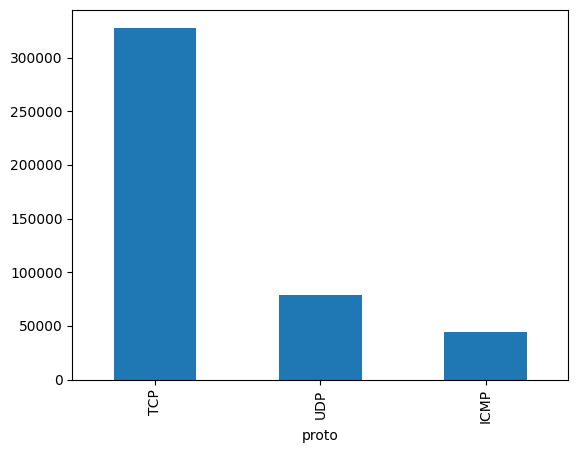

In [ ]:
df["proto"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

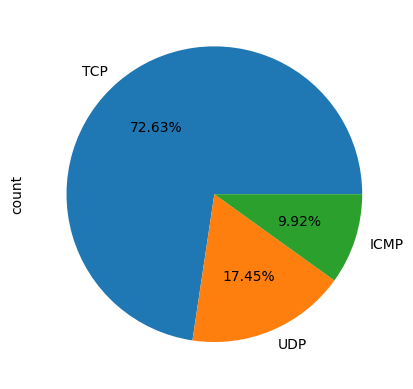

In [ ]:
df["proto"].value_counts().plot(kind="pie", autopct="%.2f%%")

Text(0.5, 1.0, 'Cyberattacks per month')

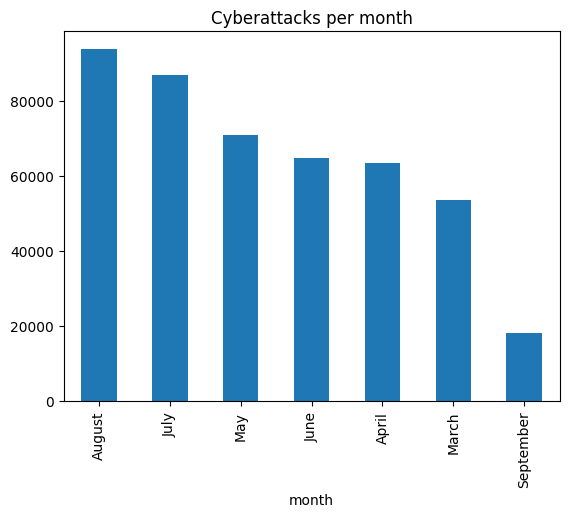

In [ ]:
df["month"].value_counts().plot(kind="bar").set_title("Cyberattacks per month")

Text(0.5, 1.0, 'Cyberattacks per day')

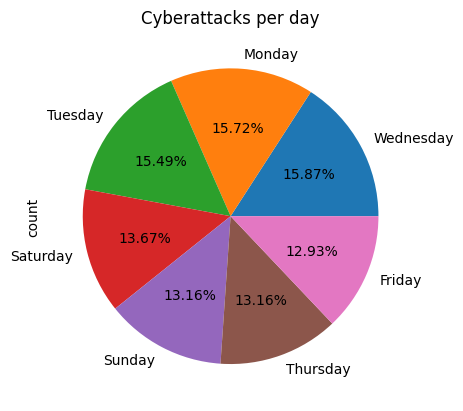

In [ ]:
df["day"].value_counts().plot(kind="pie", autopct="%.2f%%").set_title("Cyberattacks per day")

Text(0.5, 1.0, 'Cyberattacks per hour')

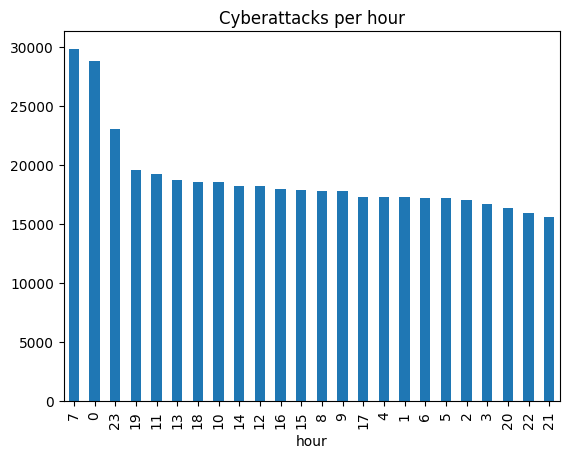

In [ ]:
df["hour"].value_counts().plot(kind="bar").set_title("Cyberattacks per hour")

<ipython-input-33-ec46e99ab92b>:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")  # Handle parsing errors gracefully


Epoch 1/30
4516/4516 ━━━━━━━━━━━━━━━━━━━━ 106s 21ms/step - accuracy: 0.6830 - loss: 0.5189 - val_accuracy: 0.8196 - val_loss: 0.3572
Epoch 2/30
4516/4516 ━━━━━━━━━━━━━━━━━━━━ 82s 18ms/step - accuracy: 0.8399 - loss: 0.2954 - val_accuracy: 0.8227 - val_loss: 0.3202
Epoch 3/30
4516/4516 ━━━━━━━━━━━━━━━━━━━━ 143s 18ms/step - accuracy: 0.8667 - loss: 0.2455 - val_accuracy: 0.8663 - val_loss: 0.2611
Epoch 4/30
4516/4516 ━━━━━━━━━━━━━━━━━━━━ 145s 19ms/step - accuracy: 0.8725 - loss: 0.2257 - val_accuracy: 0.8931 - val_loss: 0.2299
Epoch 5/30
4516/4516 ━━━━━━━━━━━━━━━━━━━━ 136s 18ms/step - accuracy: 0.8818 - loss: 0.2102 - val_accuracy: 0.8800 - val_loss: 0.2435
Epoch 6/30
4516/4516 ━━━━━━━━━━━━━━━━━━━━ 87s 19ms/step - accuracy: 0.8899 - loss: 0.2052 - val_accuracy: 0.8911 - val_loss: 0.2310
Epoch 7/30
4516/4516 ━━━━━━━━━━━━━━━━━━━━ 87s 19ms/step - accuracy: 0.8970 - loss: 0.1959 - val_accuracy: 0.8936 - val_loss: 0.2251
Epoch 8/30
4516/4516 ━━━━━━━━━━━━━━━━━━━━ 134s 17ms/step - accuracy: 0.9

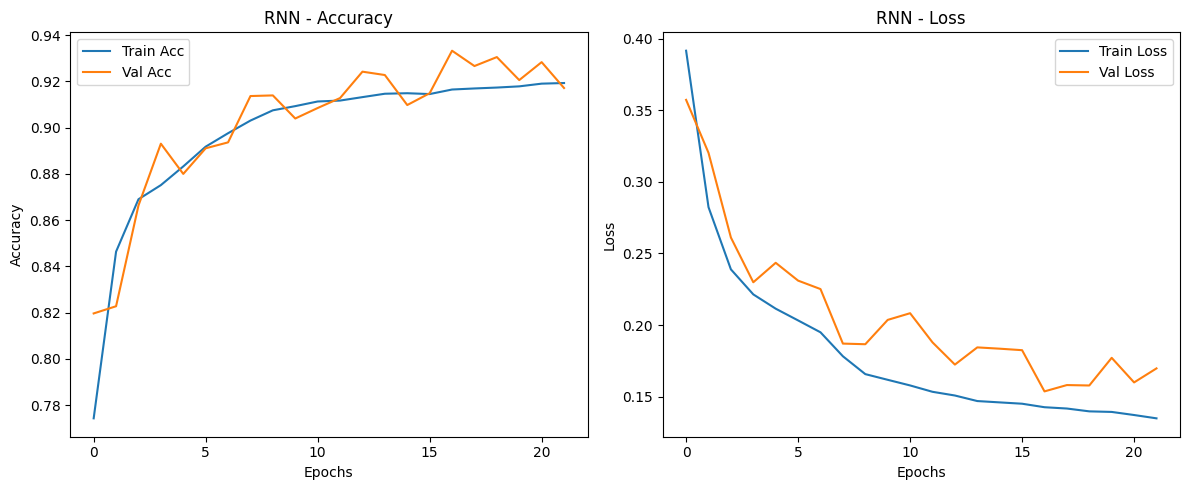

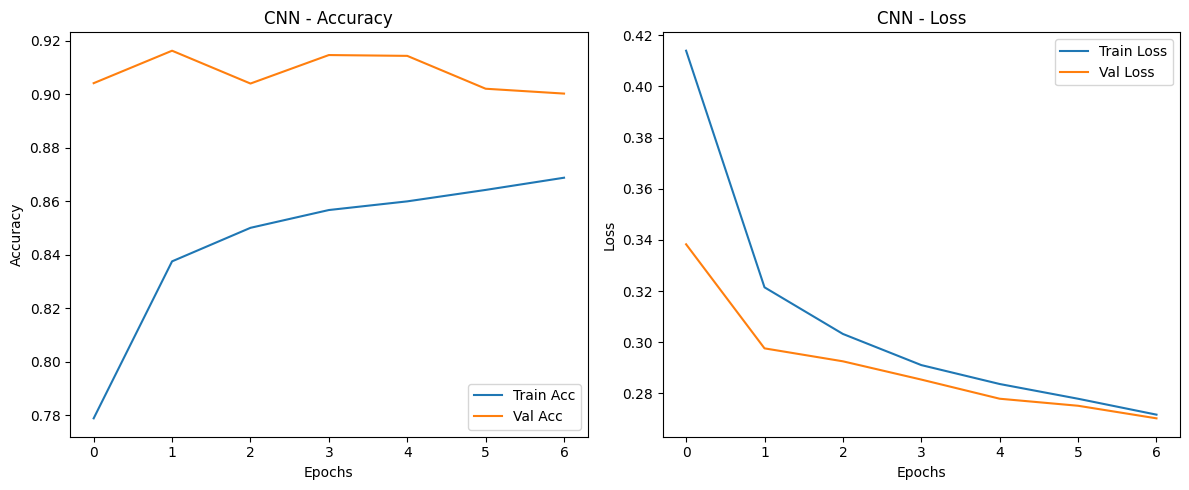

In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Conv1D, MaxPooling1D, Flatten, Input, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load Dataset
df = pd.read_csv("/content/AWS_Honeypot_marx-geo.csv")
df.drop("Unnamed: 15", axis=1, inplace=True, errors="ignore")  # Drop unused column if present
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")  # Handle parsing errors gracefully
df.dropna(subset=["datetime"], inplace=True)  # Drop rows with invalid datetime

# Feature Engineering
df["day"], df["month"], df["hour"], df["minute"] = (
    df["datetime"].dt.day,
    df["datetime"].dt.month,
    df["datetime"].dt.hour,
    df["datetime"].dt.minute,
)
df["proto"] = LabelEncoder().fit_transform(df["proto"])  # Encode target labels

# Features and Labels
features = df[["spt", "dpt", "hour", "minute", "day", "month"]].fillna(0).values  # Fill missing values
labels = df["proto"].values

# Normalize Features
scaler = MinMaxScaler()
features = scaler.fit_transform(features)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Reshape for RNN and CNN
X_train_rnn, X_test_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1]), X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
X_train_cnn, X_test_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1), X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Compute Class Weights
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

# Enhanced RNN Model
model_rnn = Sequential([
    Input(shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Bidirectional(LSTM(128, activation='relu', return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(64, activation='relu')),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(len(np.unique(labels)), activation='softmax')
])
model_rnn.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_rnn = model_rnn.fit(X_train_rnn, y_train, epochs=30, batch_size=64, validation_split=0.2,
                            class_weight=class_weights, callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)])

# Simplified CNN Model
model_cnn = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),
    Conv1D(32, kernel_size=3, activation='relu', padding='same'),  # Reduced filters
    MaxPooling1D(pool_size=2),
    Dropout(0.5),  # Increased Dropout
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),  # Reduced filters
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),  # Reduced Dense layer size
    Dropout(0.5),  # Increased Dropout
    Dense(len(np.unique(labels)), activation='softmax')
])
model_cnn.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cnn = model_cnn.fit(X_train_cnn, y_train, epochs=10, batch_size=64, validation_split=0.2,
                            class_weight=class_weights, callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)])

# Evaluate Models
rnn_eval = model_rnn.evaluate(X_test_rnn, y_test)
cnn_eval = model_cnn.evaluate(X_test_cnn, y_test)
print(f"RNN Accuracy: {rnn_eval[1] * 100:.2f}%")
print(f"CNN Accuracy: {cnn_eval[1] * 100:.2f}%")

# Plot Training History
def plot_training(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot RNN and CNN histories
plot_training(history_rnn, "RNN")
plot_training(history_cnn, "CNN")


In [34]:
#  import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler, LabelEncoder
# from sklearn.utils.class_weight import compute_class_weight
# import matplotlib.pyplot as plt
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, LSTM, Dropout, Conv1D, MaxPooling1D, Flatten, Input
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# from tensorflow.keras.layers import Bidirectional


# # Load Dataset
# df = pd.read_csv("/content/AWS_Honeypot_marx-geo.csv")
# df.drop("Unnamed: 15", axis=1, inplace=True, errors="ignore")  # Drop unused column if present
# df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")  # Handle parsing errors gracefully
# df.dropna(subset=["datetime"], inplace=True)  # Drop rows with invalid datetime

# # Feature Engineering
# df["day"], df["month"], df["hour"], df["minute"] = df["datetime"].dt.day, df["datetime"].dt.month, df["datetime"].dt.hour, df["datetime"].dt.minute
# df["proto"] = LabelEncoder().fit_transform(df["proto"])  # Encode target labels

# # Features and Labels
# features = df[["spt", "dpt", "hour", "minute", "day", "month"]].fillna(0).values  # Fill missing values
# labels = df["proto"].values

# # Normalize Features
# scaler = MinMaxScaler()
# features = scaler.fit_transform(features)

# # Train-Test Split
# X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# # Reshape for RNN and CNN
# X_train_rnn, X_test_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1]), X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
# X_train_cnn, X_test_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1), X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# # Compute Class Weights
# class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

# # RNN Model
# model_rnn = Sequential([
#     Input(shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
#     LSTM(128, activation='relu', return_sequences=True),
#     Dropout(0.3),
#     LSTM(64, activation='relu'),
#     Dropout(0.2),
#     Dense(64, activation='relu'),
#     Dense(len(np.unique(labels)), activation='softmax')
# ])
# model_rnn.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# history_rnn = model_rnn.fit(X_train_rnn, y_train, epochs=10, batch_size=64, validation_split=0.2,
#                             class_weight=class_weights, callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)])


# # Optimized CNN Model
# model_cnn = Sequential([
#     Input(shape=(X_train_cnn.shape[1], 1)),
#     Conv1D(64, kernel_size=3, activation='relu', padding='same'), # Add padding='same' to the first Conv1D layer
#     MaxPooling1D(pool_size=2),
#     Dropout(0.3),
#     Conv1D(128, kernel_size=3, activation='relu', padding='same'), # Add padding='same' to the second Conv1D layer
#     MaxPooling1D(pool_size=2),
#     Flatten(),
#     Dense(128, activation='relu'),
#     Dropout(0.2),
#     Dense(len(np.unique(labels)), activation='softmax')
# ])

# # Compile the CNN model before evaluating it
# model_cnn.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy']) # This line was missing or commented out
# history_cnn = model_cnn.fit(X_train_cnn, y_train, epochs=10, batch_size=64, validation_split=0.2,
#                             class_weight=class_weights, callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)])

# # ... (rest of the code) ...

# # Evaluate Models
# rnn_eval = model_rnn.evaluate(X_test_rnn, y_test)
# cnn_eval = model_cnn.evaluate(X_test_cnn, y_test)
# print(f"RNN Accuracy: {rnn_eval[1] * 100:.2f}%")
# print(f"CNN Accuracy: {cnn_eval[1] * 100:.2f}%")

# # Plot Training History
# def plot_training(history, title):
#     plt.figure(figsize=(12, 5))
#     plt.subplot(1, 2, 1)
#     plt.plot(history.history['accuracy'], label='Train Acc')
#     plt.plot(history.history['val_accuracy'], label='Val Acc')
#     plt.title(f'{title} - Accuracy')
#     plt.xlabel('Epochs')
#     plt.ylabel('Accuracy')
#     plt.legend()
#     plt.subplot(1, 2, 2)
#     plt.plot(history.history['loss'], label='Train Loss')
#     plt.plot(history.history['val_loss'], label='Val Loss')
#     plt.title(f'{title} - Loss')
#     plt.xlabel('Epochs')
#     plt.ylabel('Loss')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# plot_training(history_rnn, "RNN")
# plot_training(history_cnn, "CNN")
